# Room Acoustics: the Acoustic Poynting Vector, Room Modes, and PSD in an ADU

Sound design for a room is the same field theory as electrodynamics, one dictionary away. A 2-D
finite-difference time-domain (FDTD) solver gives the pressure field $p(x,y,t)$ in an
accessory-dwelling-unit floor plan, and from it three things:

1. the **acoustic Poynting vector** (intensity $\mathbf I = p\,\mathbf v$) — *where the sound energy
   flows*, the exact analog of $\mathbf S=\mathbf E\times\mathbf H$
2. the **room modes** — standing waves, i.e. the spatial frequencies the room resonates at
3. the **power spectral density** at a listener — the room's frequency response, modal peaks and nulls

| acoustics | electromagnetism (Griffiths) |
|---|---|
| pressure $p$ (scalar) | potential-like / field amplitude |
| particle velocity $\mathbf v$ | — |
| intensity $\mathbf I = p\,\mathbf v$ | Poynting $\mathbf S = \mathbf E\times\mathbf H$ |
| energy density $u=\tfrac{p^2}{2\kappa}+\tfrac{\rho|\mathbf v|^2}{2}$ | $u=\tfrac{\epsilon_0E^2}{2}+\tfrac{B^2}{2\mu_0}$ |
| $\partial_t u + \nabla\!\cdot\!\mathbf I = 0$ | Poynting's theorem |

This continues the repo's FDTD line (`pic_design/sim/fdtd_dispersion.py`), the Poynting work in the
Griffiths notebooks, and the PSD / spatial-frequency threads.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing(use_latex="mathjax")

# air at room temperature
C = 343.0          # speed of sound, m/s
RHO = 1.21         # density, kg/m^3
KAPPA = RHO*C**2   # bulk modulus, Pa  (kappa = rho c^2)
print(f"c={C} m/s, rho={RHO} kg/m^3, bulk modulus kappa={KAPPA:.0f} Pa")

c=343.0 m/s, rho=1.21 kg/m^3, bulk modulus kappa=142355 Pa


## §1 The acoustic Poynting theorem (symbolic)

Linear acoustics: $\rho\,\partial_t\mathbf v=-\nabla p$ and $\kappa^{-1}\partial_t p=-\nabla\!\cdot\!\mathbf v$.
Define the energy density $u=\dfrac{p^2}{2\kappa}+\dfrac{\rho v^2}{2}$. Then (shown here in 1-D with
SymPy; the 3-D result is identical with $pv\to p\mathbf v$):

$$\partial_t u = -\,\partial_x(p\,v)\qquad\Longrightarrow\qquad \partial_t u + \nabla\!\cdot\!(p\,\mathbf v)=0.$$

So $\mathbf I = p\,\mathbf v$ is the acoustic energy flux — the Poynting vector of sound.

In [2]:
x, t = sp.symbols("x t", real=True)
rho, kappa = sp.symbols("rho kappa", positive=True)
p = sp.Function("p")(x, t)
v = sp.Function("v")(x, t)

u = p**2/(2*kappa) + rho*v**2/2
dudt = sp.diff(u, t)
# substitute the two linearized equations: p_t = -kappa v_x, v_t = -(1/rho) p_x
dudt = dudt.subs({sp.diff(p, t): -kappa*sp.diff(v, x),
                  sp.diff(v, t): -sp.diff(p, x)/rho})
residual = sp.simplify(dudt + sp.diff(p*v, x))
display(sp.Eq(sp.Symbol("partial_t u"), sp.simplify(dudt)))
print("partial_t u + partial_x(p v) =", residual, " -> intensity I = p v is the acoustic Poynting vector")
assert residual == 0

                        ∂                     ∂          
partial_t u = - p(x, t)⋅──(v(x, t)) - v(x, t)⋅──(p(x, t))
                        ∂x                    ∂x         

partial_t u + partial_x(p v) = 0  -> intensity I = p v is the acoustic Poynting vector


## §2 A staggered-grid FDTD acoustic solver

Pressure $p$ on a grid, particle velocity $(v_x,v_y)$ on the half-grid faces (a Yee/leapfrog
scheme). Rigid walls fall out for free (zero normal velocity at the domain edge); interior
partitions are imposed by zeroing velocity on faces that touch a solid cell.

In [3]:
def make_solver(Lx, Ly, h, cfl=0.5):
    Nx, Ny = int(round(Lx/h)), int(round(Ly/h))
    dt = cfl * h / (C*np.sqrt(2))               # 2-D CFL: c*dt/h <= 1/sqrt(2)
    cv = dt/(RHO*h)
    cp = KAPPA*dt/h
    return dict(Nx=Nx, Ny=Ny, h=h, dt=dt, cv=cv, cp=cp)

def run_fdtd(cfg, source_fn, src_xy, n_steps, solid=None,
             rec_xy=None, snap_steps=None, avg_last=0, p0=None):
    Nx, Ny, h, dt, cv, cp = (cfg[k] for k in ("Nx", "Ny", "h", "dt", "cv", "cp"))
    p = np.zeros((Nx, Ny)) if p0 is None else p0.copy()
    vx = np.zeros((Nx-1, Ny))
    vy = np.zeros((Nx, Ny-1))
    if solid is None:
        solid = np.zeros((Nx, Ny), bool)
    # velocity faces adjacent to a solid cell are clamped to zero (rigid)
    fx_solid = solid[1:, :] | solid[:-1, :]
    fy_solid = solid[:, 1:] | solid[:, :-1]
    sx, sy = (int(src_xy[0]/h), int(src_xy[1]/h)) if src_xy is not None else (None, None)
    recs = {r: [] for r in (rec_xy or [])}
    snaps = {}
    Ix_acc = np.zeros_like(p); Iy_acc = np.zeros_like(p); navg = 0

    for n in range(n_steps):
        vx -= cv * (p[1:, :] - p[:-1, :]); vx[fx_solid] = 0.0
        vy -= cv * (p[:, 1:] - p[:, :-1]); vy[fy_solid] = 0.0
        # divergence over ALL cells with zero-flux (rigid) end faces -> p anti-node
        # at walls; updating only the interior freezes boundary p and kills axial modes
        dvx = np.zeros_like(p)
        dvx[0, :] = vx[0, :]; dvx[1:-1, :] = vx[1:, :] - vx[:-1, :]; dvx[-1, :] = -vx[-1, :]
        dvy = np.zeros_like(p)
        dvy[:, 0] = vy[:, 0]; dvy[:, 1:-1] = vy[:, 1:] - vy[:, :-1]; dvy[:, -1] = -vy[:, -1]
        p -= cp * (dvx + dvy)
        p[solid] = 0.0
        if source_fn is not None:
            p[sx, sy] += source_fn(n*dt)
        for r in recs:
            recs[r].append(p[int(r[0]/h), int(r[1]/h)])
        if snap_steps and n in snap_steps:
            snaps[n] = p.copy()
        if avg_last and n >= n_steps - avg_last:
            vxc = np.zeros_like(p); vyc = np.zeros_like(p)
            vxc[1:-1, :] = 0.5*(vx[1:, :] + vx[:-1, :])
            vyc[:, 1:-1] = 0.5*(vy[:, 1:] + vy[:, :-1])
            Ix_acc += p*vxc; Iy_acc += p*vyc; navg += 1

    out = dict(p=p, recs={r: np.array(v) for r, v in recs.items()}, snaps=snaps, dt=dt)
    if navg:
        out["Ix"] = Ix_acc/navg; out["Iy"] = Iy_acc/navg     # time-averaged intensity
    return out

def tone_burst(f0, n_cycles=6):
    T = n_cycles/f0
    return lambda tt: (np.sin(2*np.pi*f0*tt) * np.exp(-((tt-T/2)/(T/4))**2)
                       if tt < T else 0.0)

print("solver ready")

solver ready


## §3 The pressure field in space and time (the "4-D" view)

A 200 Hz tone burst from a speaker in a rectangular room. Snapshots at four instants show the
wavefront launch, reflection off the walls, and the standing-wave interference that builds up — a
2-D field evolving in time is the 3rd + 4th dimensions of "sound design".

grid 160x128, dt=32.2 us


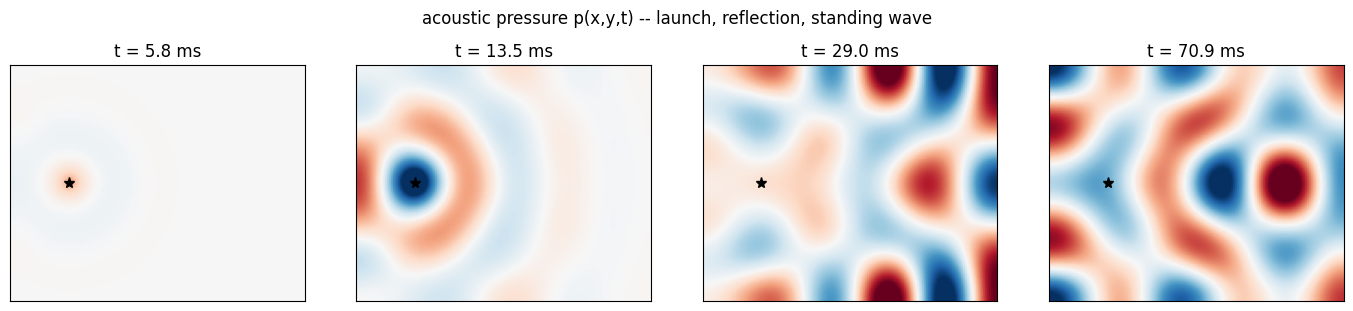

In [4]:
cfg = make_solver(5.0, 4.0, h=0.03125)
print(f"grid {cfg['Nx']}x{cfg['Ny']}, dt={cfg['dt']*1e6:.1f} us")
snap_n = [180, 420, 900, 2200]
res = run_fdtd(cfg, tone_burst(200.0), src_xy=(1.0, 2.0), n_steps=2400, snap_steps=snap_n)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.0))
vmax = max(np.abs(s).max() for s in res["snaps"].values())
for ax, n in zip(axes, snap_n):
    ax.imshow(res["snaps"][n].T, origin="lower", cmap="RdBu_r",
              vmin=-vmax*0.5, vmax=vmax*0.5, extent=[0, 5, 0, 4], aspect="equal")
    ax.set_title(f"t = {n*cfg['dt']*1000:.1f} ms"); ax.set_xticks([]); ax.set_yticks([])
    ax.plot(1.0, 2.0, "k*", ms=8)
plt.suptitle("acoustic pressure p(x,y,t) -- launch, reflection, standing wave", y=1.02)
plt.tight_layout(); plt.show()

## §4 The acoustic Poynting vector — where the energy goes (ADU floor plan)

Now an ADU floor plan: a main room and a back room separated by a partition with a **doorway**.
Drive a steady tone in the main room and time-average the intensity $\langle\mathbf I\rangle=\langle p\,\mathbf v\rangle$.
The vector field shows acoustic energy funnelling through the doorway — exactly how $\mathbf S$ shows
EM power threading an aperture.

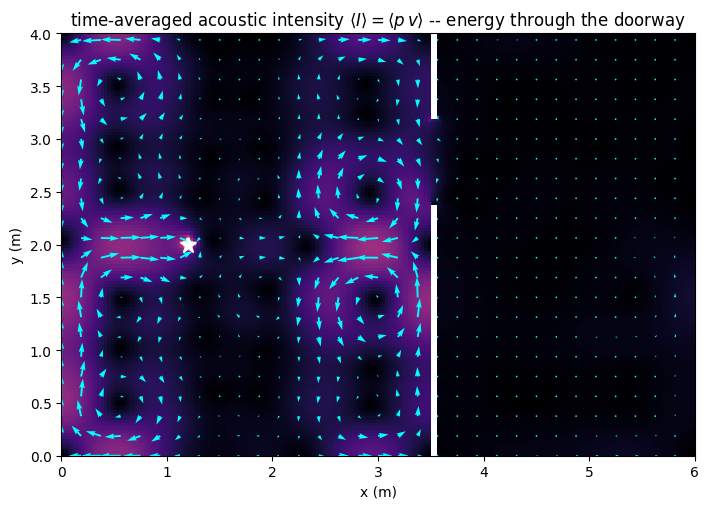

energy flux into back room concentrates at the doorway (x=3.5 m, y in 2.4-3.2 m)


In [5]:
cfg2 = make_solver(6.0, 4.0, h=0.03125)
Nx, Ny, h = cfg2["Nx"], cfg2["Ny"], cfg2["h"]
solid = np.zeros((Nx, Ny), bool)
wall_i = int(3.5/h)                                   # partition at x = 3.5 m
solid[wall_i:wall_i+2, :int(2.4/h)] = True            # leaves a doorway above y = 2.4 m
solid[wall_i:wall_i+2, int(3.2/h):] = True            # ... up to y = 3.2 m

f0 = 180.0
steady = lambda tt: np.sin(2*np.pi*f0*tt) * min(1.0, tt/0.02)
res2 = run_fdtd(cfg2, steady, src_xy=(1.2, 2.0), n_steps=3200, solid=solid,
                avg_last=int((1/f0)/cfg2["dt"]*4))     # average over ~4 periods

Ix, Iy = res2["Ix"], res2["Iy"]
mag = np.hypot(Ix, Iy)
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.imshow(np.ma.masked_where(solid, mag).T, origin="lower", cmap="magma",
          extent=[0, 6, 0, 4], aspect="equal")
step = 6
xs = np.arange(0, Nx, step)*h; ys = np.arange(0, Ny, step)*h
XX, YY = np.meshgrid(xs, ys)
U = Ix[::step, ::step].T; V = Iy[::step, ::step].T
ax.quiver(XX, YY, U, V, color="cyan", scale_units="xy", scale=mag.max()*2.0, width=0.003)
ax.imshow(np.ma.masked_where(~solid, solid).T, origin="lower", cmap="gray_r",
          extent=[0, 6, 0, 4], aspect="equal", alpha=0.9)
ax.plot(1.2, 2.0, "w*", ms=12)
ax.set_title(r"time-averaged acoustic intensity $\langle I\rangle=\langle p\,v\rangle$ -- energy through the doorway")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
plt.tight_layout(); plt.show()
print(f"energy flux into back room concentrates at the doorway (x=3.5 m, y in 2.4-3.2 m)")

## §5 Room modes = the room's spatial frequencies

A rigid rectangular room resonates at $f_{mn}=\dfrac{c}{2}\sqrt{(m/L_x)^2+(n/L_y)^2}$ with mode
shapes $\cos(m\pi x/L_x)\cos(n\pi y/L_y)$ — literally the 2-D spatial-frequency basis. These are
the eigenfunctions of the Laplacian with Neumann (rigid) walls; the "boomy" notes of a small room
are its low modes.

lowest room modes (Hz):
  (1,0):   34.3 Hz
  (0,1):   42.9 Hz
  (1,1):   54.9 Hz
  (2,0):   68.6 Hz
  (2,1):   80.9 Hz
  (0,2):   85.8 Hz
  (1,2):   92.4 Hz
  (3,0):  102.9 Hz


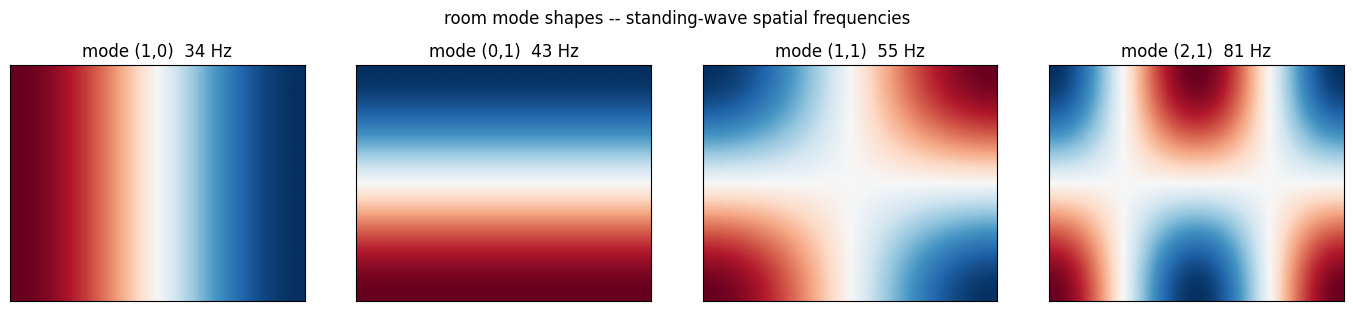

In [6]:
Lx, Ly = 5.0, 4.0
modes = []
for m in range(4):
    for n in range(4):
        if m == 0 and n == 0:
            continue
        modes.append((m, n, C/2*np.hypot(m/Lx, n/Ly)))
modes.sort(key=lambda z: z[2])
print("lowest room modes (Hz):")
for m, n, f in modes[:8]:
    print(f"  ({m},{n}): {f:6.1f} Hz")

xs = np.linspace(0, Lx, 160); ys = np.linspace(0, Ly, 128)
XX, YY = np.meshgrid(xs, ys, indexing="ij")
fig, axes = plt.subplots(1, 4, figsize=(14, 3.0))
for ax, (m, n, f) in zip(axes, [modes[0], modes[1], modes[2], modes[4]]):
    shape = np.cos(m*np.pi*XX/Lx)*np.cos(n*np.pi*YY/Ly)
    ax.imshow(shape.T, origin="lower", cmap="RdBu_r", extent=[0, Lx, 0, Ly], aspect="equal")
    ax.set_title(f"mode ({m},{n})  {f:.0f} Hz"); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("room mode shapes -- standing-wave spatial frequencies", y=1.02)
plt.tight_layout(); plt.show()

## §6 Power spectral density — the room's frequency response

Seed the room with a broadband field (spatial white noise excites every mode) and let it ring with
no losses; the recorded $p(t)$ at a microphone has a PSD $|P(f)|^2$ whose peaks land on the §5
modes. **Listener position decides what you hear**: a corner is an anti-node of *every* mode and
sees them all, while a mid-room spot sits in the *null* of any mode with a node there — the
quantitative reason where you put the desk in an ADU changes the sound.

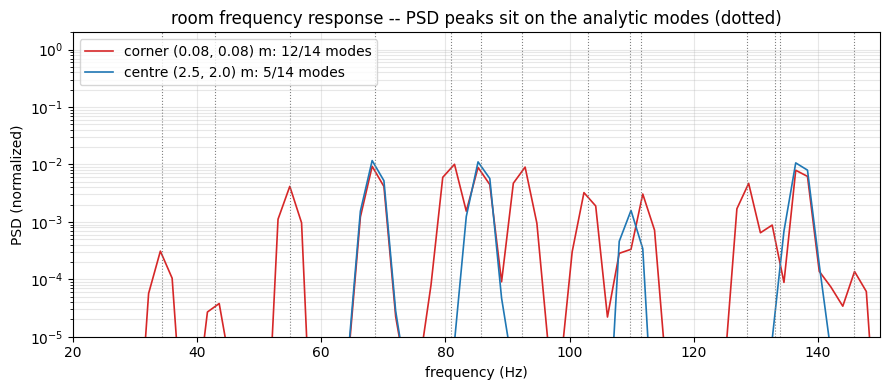

of 14 analytic modes below 150 Hz, the corner mic resolves 12, the centre mic 5 -- position picks the modes you hear.


In [7]:
cfg3 = make_solver(5.0, 4.0, h=0.03125)
dt, steps = cfg3["dt"], 16384
rng = np.random.default_rng(0)
p0 = rng.standard_normal((cfg3["Nx"], cfg3["Ny"]))*0.01
p0 -= p0.mean()                                   # drop the trivial (0,0) DC mode
mics = [(0.08, 0.08), (2.5, 2.0)]                 # corner (all anti-nodes) vs centre
res3 = run_fdtd(cfg3, None, None, steps, rec_xy=mics, p0=p0)

freqs = np.fft.rfftfreq(steps, dt)
analytic = [f for _, _, f in modes if f < 150]

def matched(sig):
    P = np.abs(np.fft.rfft(sig*np.hanning(steps)))**2
    band = (freqs >= 20) & (freqs <= 150)
    Pb, fb = P[band]/P[band].max(), freqs[band]
    loc = (Pb[1:-1] > Pb[2:]) & (Pb[1:-1] > Pb[:-2]) & (Pb[1:-1] > 0.02)
    pk = fb[1:-1][loc]
    return P, sum(1 for m in analytic if min((abs(x-m) for x in pk), default=9) < 2.5)

fig, ax = plt.subplots(figsize=(9, 4))
for (mx, my), lab, c in zip(mics, ["corner (0.08, 0.08) m", "centre (2.5, 2.0) m"], ["C3", "C0"]):
    P, nmatch = matched(res3["recs"][(mx, my)])
    ax.semilogy(freqs, P/P.max(), color=c, lw=1.2, label=f"{lab}: {nmatch}/{len(analytic)} modes")
for f in analytic:
    ax.axvline(f, color="gray", ls=":", lw=0.8)
ax.set_xlim(20, 150); ax.set_ylim(1e-5, 2)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("PSD (normalized)")
ax.set_title("room frequency response -- PSD peaks sit on the analytic modes (dotted)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

_, ncorner = matched(res3["recs"][(0.08, 0.08)])
_, ncentre = matched(res3["recs"][(2.5, 2.0)])
print(f"of {len(analytic)} analytic modes below 150 Hz, the corner mic resolves {ncorner}, "
      f"the centre mic {ncentre} -- position picks the modes you hear.")

## §7 2D → 3D → 4D, and the deployment angle

- **3-D** is the same scheme with a third axis and $v_z$; modes become $f_{\ell mn}=\tfrac{c}{2}
  \sqrt{(\ell/L_x)^2+(m/L_y)^2+(n/L_z)^2}$. The 2-D solver here is the readable slice.
- **4-D** is what §3 shows: the field is a movie, $p(x,y,t)$ — design is choosing geometry so the
  *time-and-space* energy flow (the Poynting field of §4) puts energy where the listener is and
  keeps modal nulls off the desk.
- **Game / real-time feature:** the FDTD update is pure stencil arithmetic — a `torch`
  conv2d on GPU runs it in real time, so an ADU/house-builder game could recompute room acoustics
  live as you drag a wall. The CFL bound sets the time step; the same `make_solver` numbers port
  directly to a batched tensor kernel.

**Through-lines:** acoustic intensity $p\mathbf v$ *is* a Poynting vector (Griffiths EM), room modes
*are* the 2-D spatial-frequency basis (the procedural-terrain spectrum, run as eigenmodes), and the
listener PSD is the same differential→spectral reading as `differential_vs_cumulative.ipynb`.